# 3.4 — Measuring what is left: VaR, expected shortfall, stress

> *"Risk is what's left over after you think you've thought of everything."* — Carl Richards

## The problem

Every hedge in this tutorial leaves a residual: sub-lot rounding, tenor basis, hub basis, estimation
error. The desk head does not want a standard deviation; she wants an answer to *"how much can we lose
tomorrow, with what probability, and what happens if 2022 repeats?"* — and the risk committee wants proof
that yesterday's answer was right.

This chapter turns the linear model into the three numbers that govern a hedging book in practice:

1. **Value at Risk (VaR)** and **Expected Shortfall (ES)** — parametric (Gaussian) and historical;
2. a **backtest** that checks whether the VaR was honest;
3. **stress scenarios**, including the liquidity horizon — because a residual you cannot exit in a day
   is not a one-day risk.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "gashedge").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gashedge import get_logger
from gashedge.plotting import setup_style

from scipy import stats
from gashedge.market_data import simulate_curve_history, simulate_hub_history, month_bucket, liquidity_for
from gashedge.hedging import min_variance_hedge_ratio
from gashedge.risk import (linear_pnl, portfolio_variance, parametric_var, parametric_es, historical_var,
                           historical_es, var_backtest, stress_pnl)
setup_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
log = get_logger("ch3.4")
log.info("Environment ready")

2026-09-13 16:47:16.672 | INFO    | ch3.4 | Environment ready


## 1. The residual book

Take the book from Chapter 3.1, apply the M1 + M6 minimum-variance hedge of Chapter 3.3, and add a
warehoused PEG basis position (a long PEG book hedged in TTF). The daily P&L of the residual is what we
want to measure.

2026-09-13 16:47:16.680 | INFO    | gashedge.market_data | Simulated constant-maturity curve history: 750 days x 24 tenors


2026-09-13 16:47:16.685 | INFO    | gashedge.market_data | Simulated 750 days of hub history (crisis=False); TTF range 21.7-59.9


2026-09-13 16:47:16.689 | INFO    | ch3.4 | Residual daily P&L: std 26853 EUR, skew 0.11, excess kurtosis 2.46 (Gaussian = 0)


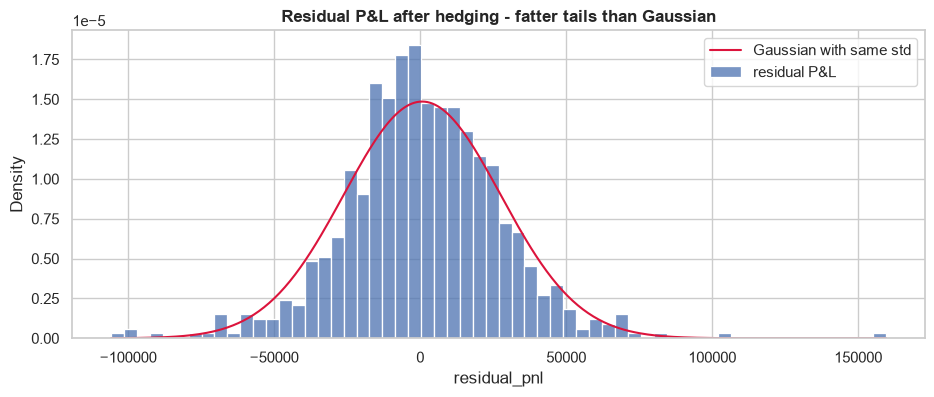

In [2]:
hist = simulate_curve_history(n_days=750, n_tenors=24)
hubs = simulate_hub_history(n_days=750, crisis=False)
d = hist.diff().dropna()
dh = hubs.diff().dropna().iloc[-len(d):]
dh.index = d.index
tenors = list(d.columns)

book = pd.Series(0.0, index=tenors)
book[["M1", "M2"]] = [18_000, -6_000]; book[["M4", "M5", "M6"]] = -12_000
book[["M13", "M14", "M15", "M16", "M17", "M18"]] = 7_000
Sigma = d.cov()
pnl_book = d.values @ book.values
S_FF = Sigma.loc[["M1", "M6"], ["M1", "M6"]].values
S_FV = np.array([np.cov(d[i], pnl_book, ddof=1)[0, 1] for i in ("M1", "M6")])
w = -np.linalg.solve(S_FF, S_FV)
hedged = book.copy(); hedged["M1"] += w[0]; hedged["M6"] += w[1]

Q_PEG = 60_000
h_hub = min_variance_hedge_ratio(dh.PEG, dh.TTF)
basis_pnl = Q_PEG * (dh.PEG - h_hub * dh.TTF)
resid = pd.Series(linear_pnl(hedged, d) + basis_pnl.values, index=d.index, name="residual_pnl")
log.info("Residual daily P&L: std %.0f EUR, skew %.2f, excess kurtosis %.2f (Gaussian = 0)", resid.std(), stats.skew(resid), stats.kurtosis(resid))
fig, ax = plt.subplots(figsize=(11, 4))
sns.histplot(resid, bins=60, stat="density", ax=ax, label="residual P&L")
xs = np.linspace(resid.min(), resid.max(), 300)
ax.plot(xs, stats.norm.pdf(xs, resid.mean(), resid.std()), color="crimson", label="Gaussian with same std")
ax.legend(); ax.set_title("Residual P&L after hedging - fatter tails than Gaussian");

## 2. Value at Risk: three ways

$\text{VaR}_\alpha$ is the loss that is exceeded with probability $1-\alpha$ over the horizon.

**Parametric (Gaussian).** With the linear model, $\Delta V \sim N(0, \mathbf{q}^\top\Sigma\mathbf{q})$, so

$$
\text{VaR}_\alpha = z_\alpha\,\sqrt{\mathbf{q}^\top\Sigma\mathbf{q}}, \qquad z_{0.99} = 2.326
\tag{3.16}
$$

**Historical.** Apply today's positions to each past day's price changes ($\mathbf{q}^\top\Delta\mathbf{P}_t$),
sort, take the empirical $(1-\alpha)$ quantile. No distributional assumption; limited by the window.

**Expected Shortfall.** The *average* loss beyond VaR — coherent, sensitive to tail shape, and the
measure regulators moved to under FRTB:

$$
\text{ES}_\alpha = \mathbb{E}[-\Delta V \mid -\Delta V > \text{VaR}_\alpha]
\quad\xrightarrow{\text{Gaussian}}\quad
\sigma\,\frac{\varphi(z_\alpha)}{1-\alpha}
\tag{3.17}
$$

In [3]:
alpha = 0.99
sigma_resid = resid.std()
var_table = pd.DataFrame({
    "parametric (Gaussian)": {"VaR99": stats.norm.ppf(alpha) * sigma_resid, "ES99": sigma_resid * stats.norm.pdf(stats.norm.ppf(alpha)) / (1 - alpha)},
    "historical": {"VaR99": historical_var(resid, alpha), "ES99": historical_es(resid, alpha)},
})
# Student-t with fitted degrees of freedom - a common fix for fat tails
df_t, loc_t, scale_t = stats.t.fit(resid)
t_q = stats.t.ppf(1 - alpha, df_t)                                  # standardised quantile (negative)
es_std_t = stats.t.pdf(t_q, df_t) * (df_t + t_q**2) / ((df_t - 1) * (1 - alpha))   # E[-T | T < t_q]
var_table["Student-t fit"] = {"VaR99": -(loc_t + scale_t * t_q), "ES99": -loc_t + scale_t * es_std_t}
log.info("99%% VaR: Gaussian %.0f vs historical %.0f (ratio %.2f); Student-t df=%.1f gives %.0f", var_table.loc["VaR99", "parametric (Gaussian)"],
         var_table.loc["VaR99", "historical"], var_table.loc["VaR99", "historical"] / var_table.loc["VaR99", "parametric (Gaussian)"], df_t, var_table.loc["VaR99", "Student-t fit"])
var_table.round(0)

2026-09-13 16:47:16.843 | INFO    | ch3.4 | 99% VaR: Gaussian 62470 vs historical 68519 (ratio 1.10); Student-t df=6.4 gives 67735


,parametric (Gaussian),historical,Student-t fit
VaR99,62470.0,68519.0,67735.0
ES99,71570.0,85162.0,86381.0


The Gaussian understates the historical 99 % VaR — gas P&L has fat tails (vol clustering, jumps). The
Student-t fit with a handful of degrees of freedom is a cheap, popular repair. But neither number is
worth much until it is **backtested**.

## 3. Backtesting: was the VaR honest?

Compute VaR each day from the trailing window, then count the days the next-day loss exceeded it. At
99 % you expect 1 % of days. Kupiec's proportion-of-failures test asks whether the observed count is
consistent with that:

$$
LR = -2\ln\!\left[\frac{(1-p)^{n-x}p^{x}}{(1-\hat p)^{n-x}\hat p^{x}}\right] \sim \chi^2_1,
\qquad p = 1-\alpha,\ \hat p = x/n
\tag{3.18}
$$

2026-09-13 16:47:16.854 | INFO    | ch3.4 | Backtest: parametric 10 exceedances vs 5.0 expected (p=0.047); historical 7 (p=0.394)


,n,exceedances,expected,kupiec_LR,p_value
parametric,499.0,10.0,4.99,3.934,0.047
historical,499.0,7.0,4.99,0.727,0.394


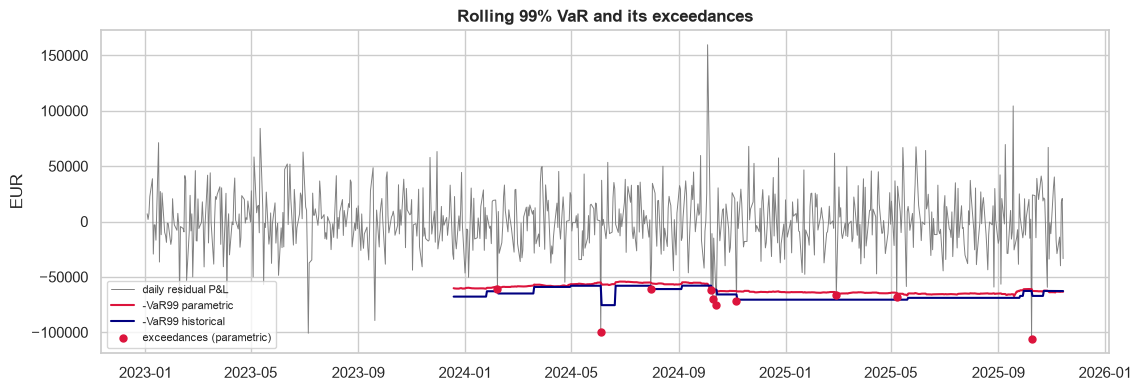

In [4]:
window = 250
var_param = resid.rolling(window).std().shift(1) * stats.norm.ppf(alpha)
var_hist = resid.rolling(window).quantile(1 - alpha).shift(1).mul(-1)
bt = pd.DataFrame({"parametric": var_backtest(resid, var_param, alpha), "historical": var_backtest(resid, var_hist, alpha)}).T
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(resid.index, resid.values, lw=0.7, color="0.5", label="daily residual P&L")
ax.plot(var_param.index, -var_param.values, color="crimson", label="-VaR99 parametric")
ax.plot(var_hist.index, -var_hist.values, color="navy", label="-VaR99 historical")
exc = resid[resid < -var_param]
ax.scatter(exc.index, exc.values, color="crimson", s=25, zorder=5, label="exceedances (parametric)")
ax.legend(loc="lower left", fontsize=8); ax.set_title("Rolling 99% VaR and its exceedances"); ax.set_ylabel("EUR")
log.info("Backtest: parametric %d exceedances vs %.1f expected (p=%.3f); historical %d (p=%.3f)",
         bt.loc["parametric", "exceedances"], bt.loc["parametric", "expected"], bt.loc["parametric", "p_value"], bt.loc["historical", "exceedances"], bt.loc["historical", "p_value"])
bt.round(3)

A p-value below 0.05 means the VaR model is rejected — it under- (or over-) states risk more than
chance allows. Too many exceedances *clustered together* is the usual failure mode: a model calibrated
on calm days is confidently wrong on all the loud ones. (Christoffersen's independence test extends
Kupiec to check clustering; rolling windows shorter than a year, or EWMA volatility, reduce it.)

## 4. Stress: the scenarios a VaR cannot see

VaR is a statement about the *observed* distribution. A stress test is a statement about a *specified*
world. For a European gas hedging book the standard set is small and brutal, and every scenario is
just a vector of price shocks pushed through the linear model, $\Delta V = \mathbf{q}^\top\Delta\mathbf{P}$:

2026-09-13 16:47:16.972 | INFO    | ch3.4 | Worst hedged stress: winter premium collapse: M13-M18 -25% -> -549 kEUR (VaR99 was 69 kEUR)


,unhedged book,hedged (M1+M6),hedged + PEG basis shock
parallel +20%,265.0,173.0,173.0
parallel -20%,-265.0,-173.0,-173.0
"front spike: M1 +60%, decaying to +5% at M24",347.0,119.0,-121.0
"curve flattens: M1 -15%, M24 +5%",5.0,69.0,69.0
"2022-style: x2.5 front, x1.6 back",1078.0,436.0,-284.0
winter premium collapse: M13-M18 -25%,-549.0,-549.0,-549.0


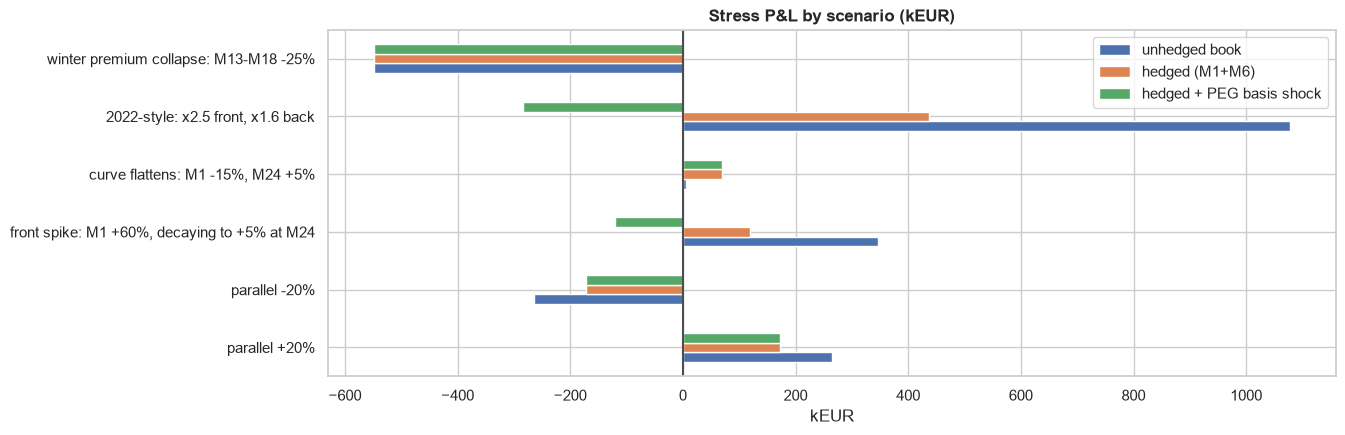

In [5]:
levels = hist.iloc[-1]
ten = np.arange(1, 25)
scenarios = {
    "parallel +20%": levels.values * 0.20,
    "parallel -20%": -levels.values * 0.20,
    "front spike: M1 +60%, decaying to +5% at M24": levels.values * (0.05 + 0.55 * np.exp(-(ten - 1) / 4)),
    "curve flattens: M1 -15%, M24 +5%": levels.values * np.linspace(-0.15, 0.05, 24),
    "2022-style: x2.5 front, x1.6 back": levels.values * (0.6 + 0.9 * np.exp(-(ten - 1) / 8)),
    "winter premium collapse: M13-M18 -25%": np.where((ten >= 13) & (ten <= 18), -0.25, 0.0) * levels.values,
}
stress = pd.DataFrame({"unhedged book": stress_pnl(book, scenarios), "hedged (M1+M6)": stress_pnl(hedged, scenarios)})
basis_shock = pd.Series({k: 0.0 for k in scenarios}); basis_shock["2022-style: x2.5 front, x1.6 back"] = -12.0; basis_shock["front spike: M1 +60%, decaying to +5% at M24"] = -4.0
stress["hedged + PEG basis shock"] = stress["hedged (M1+M6)"] + Q_PEG * basis_shock
fig, ax = plt.subplots(figsize=(13, 4.5))
(stress / 1e3).plot.barh(ax=ax); ax.axvline(0, color="0.3"); ax.set_xlabel("kEUR"); ax.set_title("Stress P&L by scenario (kEUR)")
log.info("Worst hedged stress: %s -> %.0f kEUR (VaR99 was %.0f kEUR)", stress["hedged + PEG basis shock"].idxmin(), stress["hedged + PEG basis shock"].min() / 1e3, var_table.loc["VaR99", "historical"] / 1e3)
(stress / 1e3).round(0)

Two things a hedger learns from the stress table that no VaR would tell:

* The hedge protects against **parallel** moves but is exposed to **shape** (the flattening and the
  winter-premium scenarios), because it neutralised level, not slope — exactly Chapter 3.3's point.
* The **hub basis** shock in a 2022-style scenario is several *times* the daily VaR. A warehoused basis
  that is a rounding error in daily variance is the dominant loss under stress. Limits must be set on
  *both* measures.

## 5. Liquidity horizon: a residual you cannot exit is not a one-day risk

VaR scales with the square root of the holding period under i.i.d. changes: $\text{VaR}_h = \text{VaR}_1\sqrt{h}$.
The honest horizon for a position is the time to exit it at acceptable participation (equation 1.9), so
a **liquidity-adjusted VaR** weights each position by its own horizon:

$$
\text{LVaR} = z_\alpha\sqrt{\tilde{\mathbf{q}}^\top\Sigma\,\tilde{\mathbf{q}}},\qquad
\tilde q_i = q_i\sqrt{T_i},\quad T_i = \frac{|q_i|/H}{\pi\,\text{ADV}_i}
\tag{3.19}
$$

(A common simplification; it treats each position's exit as independent, which overstates slightly.)
For our small example book every position exits within a day, so we scale it up to see the effect: the
far-winter strip, in thin M13+ contracts, is where the horizon bites.

In [6]:
def liquidity_horizon(q_mwh, tenor, participation=0.10, lot_mwh=730):
    adv = liquidity_for(month_bucket(tenor), "TTF")["est_adv_lots"]
    return max(1.0, abs(q_mwh) / lot_mwh / (participation * adv))

SCALE = 8                                  # a book eight times the size of our example - a mid-sized desk
big = hedged * SCALE
T = pd.Series([liquidity_horizon(big[t], i + 1) for i, t in enumerate(tenors)], index=tenors)
q_tilde = big * np.sqrt(T)
lvar = parametric_var(q_tilde, Sigma, alpha)
var1 = parametric_var(big, Sigma, alpha)
log.info("Book x%d: 1-day parametric VaR99 %.0f EUR -> liquidity-adjusted %.0f EUR (x%.2f); longest horizon %.1f days at %s",
         SCALE, var1, lvar, lvar / var1, T.max(), T.idxmax())
pd.DataFrame({"position_mwh": big, "horizon_days": T}).loc[lambda x: x.position_mwh != 0].round(1)

2026-09-13 16:47:17.070 | INFO    | ch3.4 | Book x8: 1-day parametric VaR99 241807 EUR -> liquidity-adjusted 500031 EUR (x2.07); longest horizon 3.1 days at M13


,position_mwh,horizon_days
M1,110311.3,1.0
M2,-48000.0,1.0
M4,-96000.0,1.0
M5,-96000.0,1.0
M6,-117935.4,1.0
M13,56000.0,3.1
M14,56000.0,3.1
M15,56000.0,3.1
M16,56000.0,3.1
M17,56000.0,3.1


## 6. Where this leaves us

A hedging book is governed by three numbers — VaR/ES (statistical), stress (scenario), and liquidity
horizon (exit) — all computed from the same delta vector through the linear model. Backtesting keeps the
first honest; the second and third catch what the first cannot.

**Pitfall that leads to the next chapter:** every number here used a covariance matrix estimated over a
fixed window, and every hedge ratio in the tutorial did the same. The backtest hinted at the problem:
exceedances cluster because the world changes faster than a 250-day window. Chapter 3.5 confronts
non-stationarity directly — rolling and exponentially weighted estimates, regime shifts, shrinkage — and
closes the tutorial with what to do when you know your model is wrong.

### Check your understanding

Work these on paper (or in a scratch cell) *before* expanding the answers.

**Q1.** A hedged residual has daily standard deviation €25,000. Compute the Gaussian 99 % one-day VaR and ES. If the historical 99 % VaR turns out to be €72,000, what does that tell you about the distribution, and which of the two numbers would you put in the limit framework?

<details><summary><i>Answer 1</i></summary>

Gaussian VaR$_{99}$ $= 2.326\times25{,}000 = \mathbf{€58{,}150}$; ES$_{99}$ $= 25{,}000\times\varphi(2.326)/0.01 = 25{,}000\times0.02665/0.01 = \mathbf{€66{,}600}$. A historical VaR of 72,000 — 24 % above Gaussian and even above the Gaussian ES — says the residual has **fat tails** (excess kurtosis), typical of basis and gas P&L. Use the **historical (or Student-t) number**, and preferably **ES** rather than VaR, in the limit framework; a Gaussian VaR would be breached far more often than 1 % of days and fail its backtest.

</details>

**Q2.** Over 500 days a 99 % VaR model shows 11 exceedances. Compute the Kupiec statistic (3.18) and decide at the 5 % level ($\chi^2_1$ critical value 3.84) whether to reject the model. What extra check would you run before concluding?

<details><summary><i>Answer 2</i></summary>

$n=500, x=11, p=0.01, \hat p = 0.022$. $LR = -2[\,(489)\ln(0.99) + 11\ln(0.01) - 489\ln(0.978) - 11\ln(0.022)\,]$ $= -2[\,-4.914 - 50.656 + 10.878 + 41.985\,] = -2(-2.707) = \mathbf{5.41} > 3.84$ → **reject**: 11 is too many (expected 5). Extra check: **clustering** — if the 11 exceedances fall in one month (a crisis), the failure is a *volatility-updating* problem (window too long / not reactive), best fixed with EWMA or a shorter window (Christoffersen independence test); if they are scattered, the *tail shape* is wrong (use historical/Student-t).

</details>

**Q3.** Explain why a book that is level-hedged (PC1 exposure zero) can still show a large loss in the 'curve flattens' scenario, and how you would decide whether to hedge that exposure.

<details><summary><i>Answer 3</i></summary>

'Curve flattens' is predominantly a **slope (PC2)** shock: the front falls and the back rises. A level hedge sets $\mathbf{q}^\top v_1 = 0$ but leaves $\mathbf{q}^\top v_2 \neq 0$ — in the example the book is long front / short middle / long far winter, a large slope exposure. Decide with the trade-off of Chapter 2.1/2.5: the *risk* removed is $\beta_2^2\lambda_2$ (equation 3.15 — check its share of variance and its stress loss), the *cost* is a second instrument's spread and roll (e.g. a season or M6–M12), and the *estimation risk* of a two-instrument hedge (Chapter 3.3 condition number). If the slope stress exceeds the stress limit or $\beta_2^2\lambda_2$ is a material share of variance, hedge it; otherwise report and carry it.

</details>

**Q4.** A residual position of 8,000 MWh sits in a tenor with estimated ADV 250 lots (730 MWh each). At 10 % participation what is its liquidity horizon, and by what factor does its contribution to VaR scale under (3.19)? Suggest one action that reduces LVaR *without* trading the illiquid tenor.

<details><summary><i>Answer 4</i></summary>

Lots $= 8{,}000/730 = 10.96$; horizon $T = 10.96/(0.10\times250) = 0.44$ days → floored to **1 day** (it can be exited within a day). Scaling factor $\sqrt{T} = 1$ — no add-on. (Had the position been 80,000 MWh, $T = 4.4$ days and the contribution scales by $\sqrt{4.4} = 2.1$.) Action without trading the illiquid tenor: **hedge its level risk in the liquid front** (stack), so that the *un-exitable* residual is only the tenor spread, whose volatility is a fraction of the outright — LVaR falls because $\Sigma$-weighted size, not the horizon, shrinks. Alternatively raise participation with a spread order (M1/Mk calendar spread) which is more liquid than the outright.

</details>


---
◀ [Previous](03_multi_instrument_and_pca.ipynb) · [Contents](../00_introduction.ipynb) · [Next ▶](05_estimation_error_and_regimes.ipynb)